NAV Analysis Period:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Number of schemes: 40
Number of records: 46000


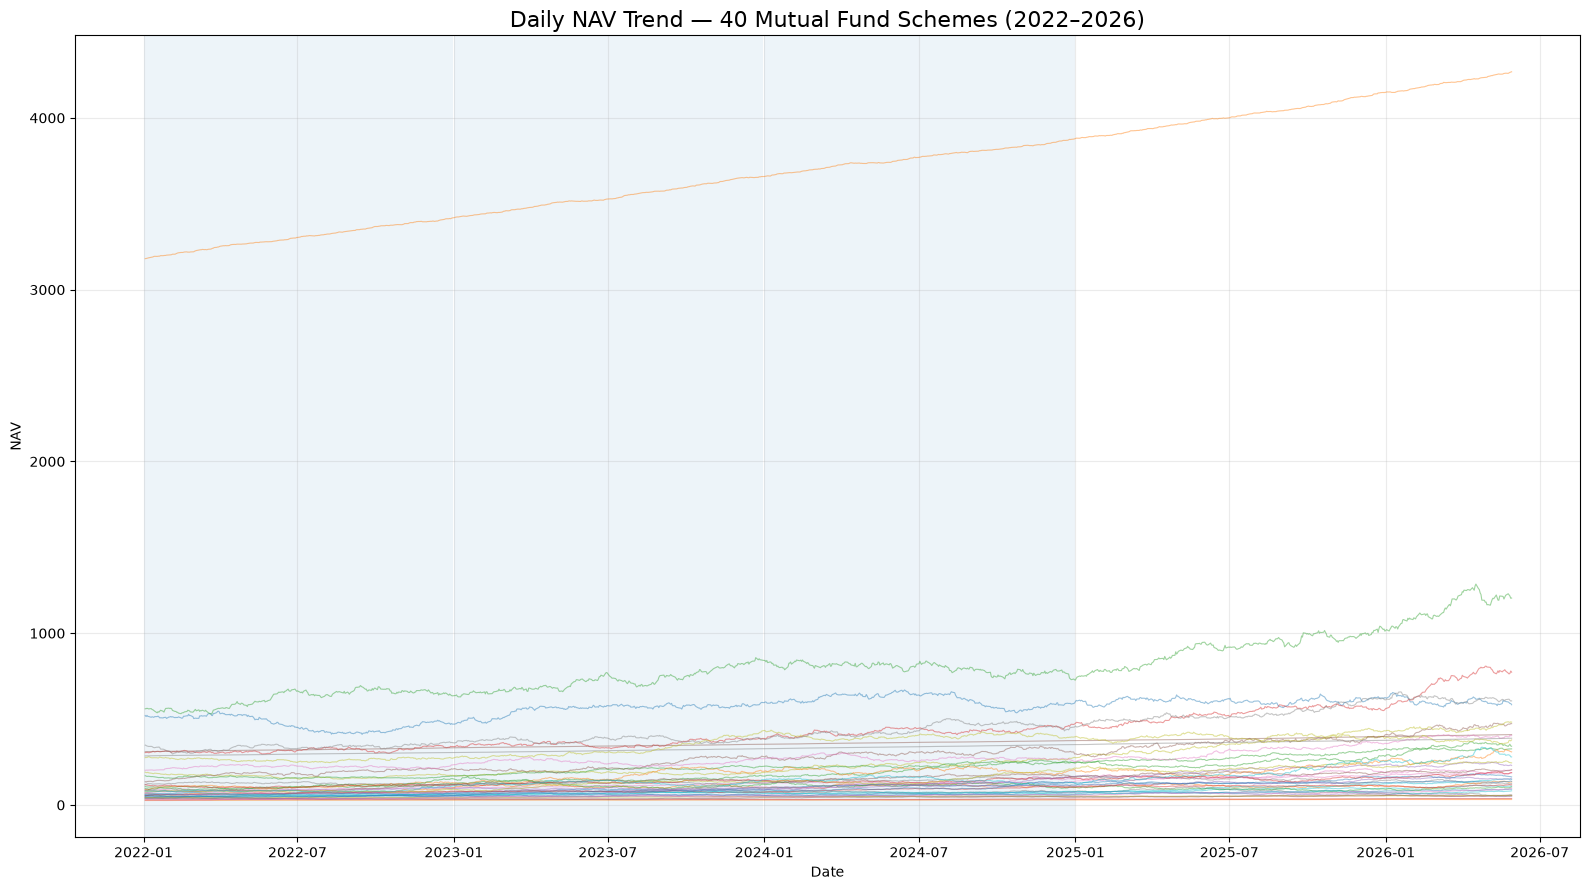


NAV trend chart created successfully.
Saved to: Reports/NAV_Trend_Analysis.png


In [ ]:
# DAY 3 - TASK 1: NAV TREND ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt

# Loading cleaned NAV data:
nav_df = pd.read_csv("../Data/Processed/nav_history_cleaned.csv")

# Converting date column to datetime:
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")

# Create analysis dataframe:
nav = nav_df.dropna(subset=["date"]).copy()

# Sort by date:
nav = nav.sort_values("date")

# Keep required period: 2022-2026:
nav = nav[
    (nav["date"] >= "2022-01-01") &
    (nav["date"] <= "2026-12-31")
]

# Basic information:
print("NAV Analysis Period:")
print(nav["date"].min(), "to", nav["date"].max())

print("\nNumber of schemes:", nav["amfi_code"].nunique())
print("Number of records:", len(nav))

# Create NAV trend chart:
plt.figure(figsize=(16, 9))

for scheme_code, group in nav.groupby("amfi_code"):
    plt.plot(
        group["date"],
        group["nav"],
        linewidth=0.8,
        alpha=0.45
    )

# Highlight important periods:
plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.08
)

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.08
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.08
)

# Chart formatting:
plt.title(
    "Daily NAV Trend — 40 Mutual Fund Schemes (2022–2026)",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.grid(True, alpha=0.25)

plt.tight_layout()

# Save chart:
plt.savefig(
    "../Reports/NAV_Trend_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nNAV trend chart created successfully.")
print("Saved to: Reports/NAV_Trend_Analysis.png")